# Masked GRU sweep across hidden sizes — v8

Sweeps the **masked** GRU across hidden sizes to see performance as a function of model size. Each masked
model has **self-connections only**: hidden neuron i connects to itself but not to any other hidden neuron,
enforced on **every forward pass**, so it holds during both training and testing.

Mechanically, the hidden-to-hidden weight is multiplied by a fixed binary mask each forward pass. PyTorch
stacks the three GRU gate blocks in the recurrent weight, so for hidden size H the recurrent weight is
(3H, H) and the mask is the H×H identity tiled three times. That zeros every off-diagonal element in all
three gate blocks, leaving only neuron-to-self weights, for any H.

The standard (fully-connected) GRU is swept alongside, so the cost of removing cross-connections is visible
against size. Loads `./generated_trials_v8`.

## 1. Setup

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")
DATA_DIR = Path("./generated_trials_v8"); OUT_DIR = Path("./masked_sweep_v8"); OUT_DIR.mkdir(exist_ok=True)

## 2. Load data and subtask groups

In [14]:
def load(split):
    d = np.load(DATA_DIR / f"{split}.npz", allow_pickle=True)
    return {"X": d["X"].astype(np.float32), "y": d["y_4class"].astype(np.int64), "types": d["types"]}
train, test = load("train"), load("test")
SUBTASKS = sorted(set(test["types"]))
CONFLICT = ["det_multisensory", "loc_conflict_audL_visR", "loc_conflict_audR_visL"]

SUBTASK_STYLE = {}
for s in SUBTASKS:
    if s.startswith("det"): c = "tab:orange"
    elif "conflict" in s: c = "tab:blue"
    else: c = "tab:cyan"
    SUBTASK_STYLE[s] = {"color": c, "ls": "--" if "conflict" in s else "-"}
print("Train", train["X"].shape, " Test", test["X"].shape)

Train (4800, 4, 50)  Test (1200, 4, 50)


## 3. Masked GRU (self-connections only) and standard GRU

`MaskedGRU` is a hand-written GRU cell whose recurrent matrix is `weight_hh * mask`. The mask is built once
as `torch.eye(H).repeat(3, 1)` and applied on every forward pass, so no cross-neuron connection ever exists
in training or testing. The standard GRU uses `nn.GRU` directly.

In [16]:
class MaskedGRU(nn.Module):
    def __init__(self, n_in=4, hidden=2, n_out=4):
        super().__init__(); self.H = hidden
        s = 1.0 / math.sqrt(hidden)
        self.weight_ih = nn.Parameter(torch.empty(3*hidden, n_in).uniform_(-s, s))
        self.weight_hh = nn.Parameter(torch.empty(3*hidden, hidden).uniform_(-s, s))
        self.bias_ih   = nn.Parameter(torch.empty(3*hidden).uniform_(-s, s))
        self.bias_hh   = nn.Parameter(torch.empty(3*hidden).uniform_(-s, s))
        self.readout   = nn.Linear(hidden, n_out)
        # mask: identity per gate block -> only neuron-to-self recurrent weights survive
        self.register_buffer("mask", torch.eye(hidden).repeat(3, 1))   # (3H, H)

    def masked_hh(self):
        return self.weight_hh * self.mask          # enforced every forward pass

    def forward(self, x):
        x = x.transpose(1, 2); B, Tt, _ = x.shape; H = self.H
        Whh = self.masked_hh()
        Wir, Wiz, Win = self.weight_ih[:H], self.weight_ih[H:2*H], self.weight_ih[2*H:]
        Whr, Whz, Whn = Whh[:H], Whh[H:2*H], Whh[2*H:]
        bir, biz, bin_ = self.bias_ih[:H], self.bias_ih[H:2*H], self.bias_ih[2*H:]
        bhr, bhz, bhn = self.bias_hh[:H], self.bias_hh[H:2*H], self.bias_hh[2*H:]
        h = x.new_zeros(B, H); outs = []
        for t in range(Tt):
            xt = x[:, t, :]
            r = torch.sigmoid(xt @ Wir.T + bir + h @ Whr.T + bhr)
            z = torch.sigmoid(xt @ Wiz.T + biz + h @ Whz.T + bhz)
            n = torch.tanh(xt @ Win.T + bin_ + r * (h @ Whn.T + bhn))
            h = (1 - z) * n + z * h
            outs.append(self.readout(h))
        return torch.stack(outs, 1)

class StandardGRU(nn.Module):
    def __init__(self, n_in=4, hidden=2, n_out=4):
        super().__init__(); self.gru = nn.GRU(n_in, hidden, batch_first=True); self.readout = nn.Linear(hidden, n_out)
    def forward(self, x):
        x = x.transpose(1, 2); h, _ = self.gru(x); return self.readout(h)

def off_diagonal_max(model):
    W = model.masked_hh().detach().numpy().reshape(3, model.H, model.H)
    return float(np.abs(W - np.stack([np.diag(np.diag(W[g])) for g in range(3)])).max())

## 4. Train / evaluate helpers

In [17]:
def train_model(kind, hidden, seed, n_epochs=50, lr=1e-3, batch=64):
    torch.manual_seed(seed); np.random.seed(seed)
    model = (MaskedGRU if kind == "masked" else StandardGRU)(4, hidden, 4).to(device)
    loader = DataLoader(TensorDataset(torch.from_numpy(train["X"]), torch.from_numpy(train["y"])),
                        batch_size=batch, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr); loss_fn = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        model.train()
        for Xb, yb in loader:
            logits = model(Xb); B, Tt, C = logits.shape
            loss = loss_fn(logits.reshape(B*Tt, C), yb.unsqueeze(1).expand(B, Tt).reshape(B*Tt))
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def evaluate(model):
    model.eval()
    with torch.no_grad(): pred = model(torch.from_numpy(test["X"]))[:, -1, :].argmax(-1).numpy()
    overall = float((pred == test["y"]).mean())
    per = {s: float((pred[test["types"] == s] == test["y"][test["types"] == s]).mean()) for s in SUBTASKS}
    return overall, per

## 5. Sweep config

Masked and standard GRU, 1-8 units, 5 seeds. This is the slow cell (80 trainings).

In [18]:
HIDDEN_SIZES = list(range(1, 9))
SEEDS = [0, 1, 2, 3, 4]
KINDS = ["masked", "standard"]
N_EPOCHS = 50
print("Trainings:", len(KINDS)*len(HIDDEN_SIZES)*len(SEEDS))

Trainings: 80


## 6. Run the sweep (verifying the mask holds at every size)

In [6]:
import time
res = {k: {h: {"overall": [], "per": {s: [] for s in SUBTASKS}} for h in HIDDEN_SIZES} for k in KINDS}
offdiag_check = []
t0 = time.time()
for k in KINDS:
    print("KIND:", k)
    for h in HIDDEN_SIZES:
        ov_list = []; ts = time.time()
        for seed in SEEDS:
            m = train_model(k, h, seed, N_EPOCHS)
            if k == "masked": offdiag_check.append(off_diagonal_max(m))
            ov, per = evaluate(m); ov_list.append(ov)
            res[k][h]["overall"].append(ov)
            for s in SUBTASKS: res[k][h]["per"][s].append(per[s])
        print("  h=%d  overall mean=%.3f std=%.3f  (%.1fs)" % (h, np.mean(ov_list), np.std(ov_list), time.time()-ts))
print("Total sweep time: %.1f min" % ((time.time()-t0)/60))
print("Masked off-diagonal magnitude across all trained models: max = %.1e (should be ~0)" % (max(offdiag_check) if offdiag_check else 0))

KIND: masked
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) i

## 7. Performance vs model size: masked vs standard

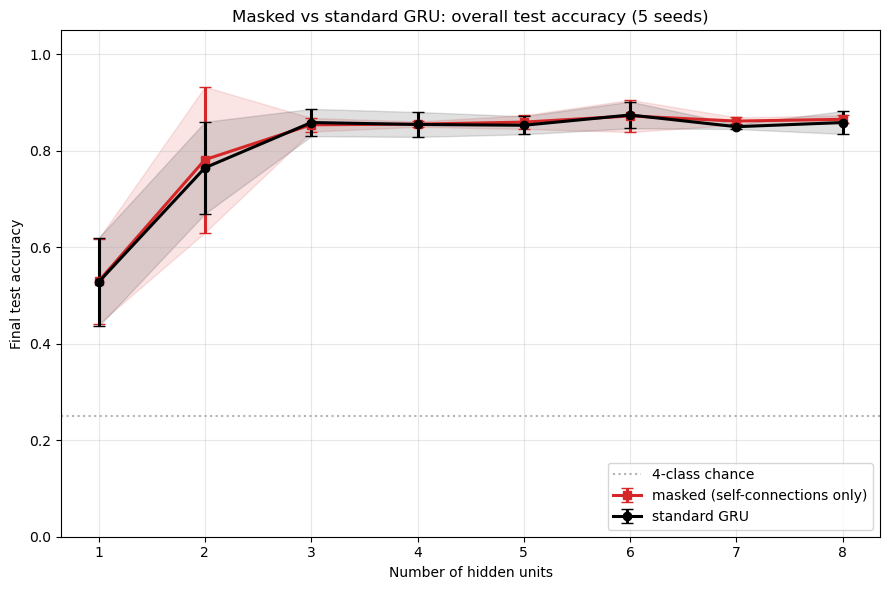


 Hidden  masked mean  masked std  standard mean     gap
--------------------------------------------------------
      1        0.530       0.088          0.528  -0.002
      2        0.782       0.151          0.765  -0.017
      3        0.854       0.014          0.859   0.005
      4        0.855       0.006          0.855  -0.001
      5        0.860       0.014          0.853  -0.006
      6        0.872       0.033          0.875   0.002
      7        0.862       0.008          0.850  -0.012
      8        0.865       0.008          0.859  -0.007


In [7]:
style = {"masked": ("tab:red", "s", "masked (self-connections only)"), "standard": ("black", "o", "standard GRU")}
fig, ax = plt.subplots(figsize=(9, 6))
for k in KINDS:
    m = np.array([np.mean(res[k][h]["overall"]) for h in HIDDEN_SIZES])
    sd = np.array([np.std(res[k][h]["overall"]) for h in HIDDEN_SIZES])
    col, mk, lab = style[k]
    ax.errorbar(HIDDEN_SIZES, m, yerr=sd, marker=mk, lw=2.2, capsize=4, color=col, label=lab)
    ax.fill_between(HIDDEN_SIZES, m - sd, m + sd, color=col, alpha=0.12)
ax.axhline(0.25, color="gray", ls=":", alpha=0.6, label="4-class chance")
ax.set_xlabel("Number of hidden units"); ax.set_ylabel("Final test accuracy")
ax.set_xticks(HIDDEN_SIZES); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend(loc="lower right")
ax.set_title("Masked vs standard GRU: overall test accuracy (5 seeds)")
plt.tight_layout(); plt.savefig(OUT_DIR / "masked_sweep_overall.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"\n{'Hidden':>7} {'masked mean':>12} {'masked std':>11} {'standard mean':>14} {'gap':>7}")
print("-"*56)
for h in HIDDEN_SIZES:
    mm, ms = res["masked"][h]["overall"], res["standard"][h]["overall"]
    print(f"{h:>7} {np.mean(mm):>12.3f} {np.std(mm):>11.3f} {np.mean(ms):>14.3f} {np.mean(ms)-np.mean(mm):>7.3f}")

## 8. Per-subtask accuracy for the masked model

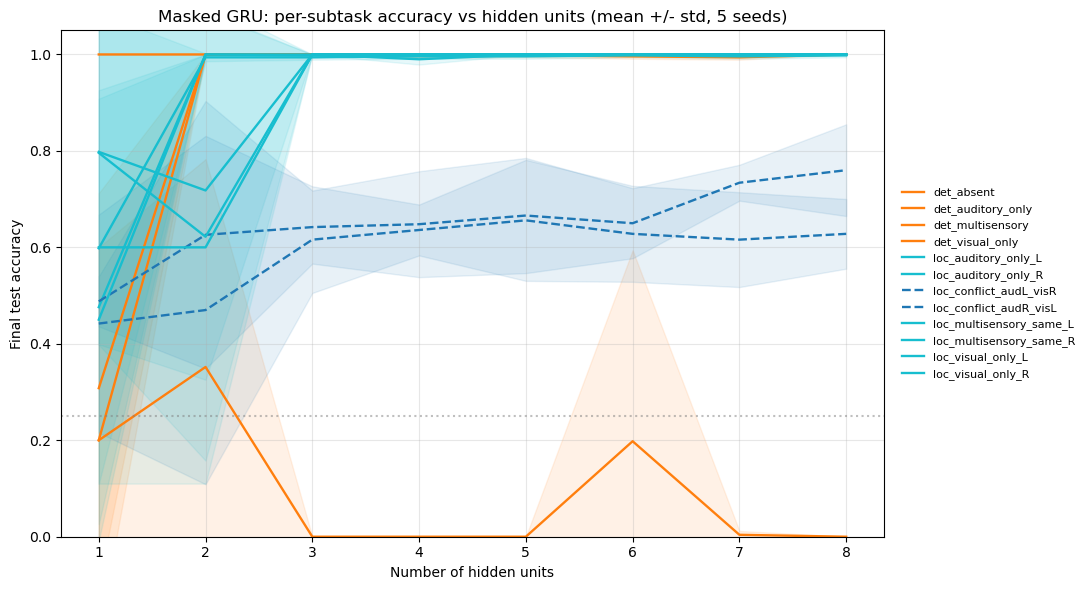

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for s in SUBTASKS:
    m = np.array([np.mean(res["masked"][h]["per"][s]) for h in HIDDEN_SIZES])
    sd = np.array([np.std(res["masked"][h]["per"][s]) for h in HIDDEN_SIZES])
    st = SUBTASK_STYLE[s]
    ax.plot(HIDDEN_SIZES, m, color=st["color"], ls=st["ls"], lw=1.7, label=s)
    ax.fill_between(HIDDEN_SIZES, m - sd, m + sd, color=st["color"], alpha=0.10)
ax.axhline(0.25, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Number of hidden units"); ax.set_ylabel("Final test accuracy")
ax.set_xticks(HIDDEN_SIZES); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
ax.set_title("Masked GRU: per-subtask accuracy vs hidden units (mean +/- std, 5 seeds)")
plt.tight_layout(); plt.savefig(OUT_DIR / "masked_sweep_persubtask.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Verdict and save

In [9]:
plateau = [h for h in HIDDEN_SIZES if h >= 3]
m_plat = np.mean([np.mean(res["masked"][h]["overall"]) for h in plateau])
s_plat = np.mean([np.mean(res["standard"][h]["overall"]) for h in plateau])
print("Plateau (h>=3) mean overall:  masked %.3f   standard %.3f   gap %.3f" % (m_plat, s_plat, s_plat - m_plat))
ok = [h for h in HIDDEN_SIZES if np.mean(res["masked"][h]["overall"]) >= s_plat - 0.03]
print("Smallest masked size within 0.03 of the standard plateau:", ok[0] if ok else "none in 1-8")
if s_plat - m_plat < 0.03:
    print("\nVerdict: removing cross-connections costs little once the model is a few units wide.")
elif s_plat - m_plat < 0.08:
    print("\nVerdict: a small but real cost to removing cross-connections; the masked model needs a bit more width.")
else:
    print("\nVerdict: cross-connections matter; the masked model lags and may need more units to compensate.")

np.savez(OUT_DIR / "masked_sweep_v8.npz", res=np.array(res, dtype=object),
         hidden_sizes=np.array(HIDDEN_SIZES), seeds=np.array(SEEDS))
print("Saved to", OUT_DIR / "masked_sweep_v8.npz")

Plateau (h>=3) mean overall:  masked 0.862   standard 0.858   gap -0.003
Smallest masked size within 0.03 of the standard plateau: 3

Verdict: removing cross-connections costs little once the model is a few units wide.
Saved to masked_sweep_v8/masked_sweep_v8.npz


200 conflict trials, gap range 0.00 to 1.95
  h=2 seed=0  pooled agreement = 0.555
  h=2 seed=1  pooled agreement = 0.130
  h=2 seed=2  pooled agreement = 0.490
  h=2 seed=3  pooled agreement = 0.580
  h=2 seed=4  pooled agreement = 0.375
  h=3 seed=0  pooled agreement = 0.390
  h=3 seed=1  pooled agreement = 0.625
  h=3 seed=2  pooled agreement = 0.650
  h=3 seed=3  pooled agreement = 0.505
  h=3 seed=4  pooled agreement = 0.620
  h=5 seed=0  pooled agreement = 0.835
  h=5 seed=1  pooled agreement = 0.545
  h=5 seed=2  pooled agreement = 0.620
  h=5 seed=3  pooled agreement = 0.570
  h=5 seed=4  pooled agreement = 0.530
Saved predictions to Ag_conflict_v8_standard.npz

A(g): agreement with the stronger cue, mean +/- std across 5 seeds  (standard GRU)
  gap bin              0.13           0.39           0.64           0.96           1.55
  -------------------------------------------------------------------------------------
  2 units     0.27 +/- 0.20   0.40 +/- 0.21   0.40 +/- 0.24   

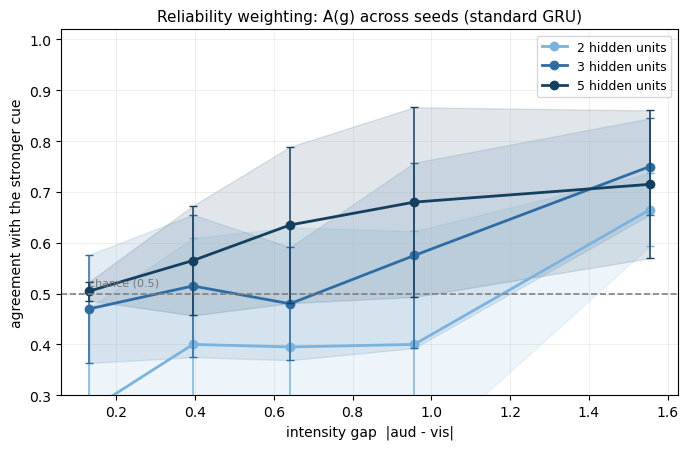


Saved figure to masked_sweep_v8/Ag_reliability_curve_standard.png

Pooled agreement over ALL conflict trials (the conservative number):
  h=2: 0.426
  h=3: 0.558
  h=5: 0.620
A rising A(g) alongside a modest pooled value is the signature of
reliability weighting; a fixed-side policy would stay flat near 0.5.


In [20]:
#  A(g): reliability weighting as a function of the intensity gap
import numpy as np, torch, matplotlib.pyplot as plt

SIZES     = [2, 3, 5]          # sizes that carry the argument in the report
KIND      = "standard"         # "standard" or "masked"
N_BINS    = 5
CACHE     = OUT_DIR / f"Ag_conflict_v8_{KIND}.npz"
CONFLICTS = ["loc_conflict_audL_visR", "loc_conflict_audR_visL"]

# ------------------------------------------------- intensities (THE FIX)
# nb09's load() drops aud_int/vis_int, so read them from the npz directly.
_raw     = np.load(DATA_DIR / "test.npz", allow_pickle=True)
_aud     = _raw["aud_int"]
_vis     = _raw["vis_int"]

conf_mask = np.isin(test["types"], CONFLICTS)
gap       = np.abs(_aud - _vis)[conf_mask]     # |aud - vis|, the reliability gap
y_conf    = test["y"][conf_mask]               # already the "stronger cue wins" label
print(f"{conf_mask.sum()} conflict trials, gap range {gap.min():.2f} to {gap.max():.2f}")

# ------------------------------------------------------------ train / load
if CACHE.exists():
    preds = np.load(CACHE, allow_pickle=True)["preds"].item()
    print(f"Loaded cached predictions from {CACHE.name} (no retraining).")
else:
    preds = {}
    for h in SIZES:
        for s in SEEDS:
            model = train_model(KIND, h, s)
            model.eval()
            with torch.no_grad():
                p = model(torch.from_numpy(test["X"]))[:, -1, :].argmax(-1).numpy()
            preds[(h, s)] = p[conf_mask]
            print(f"  h={h} seed={s}  pooled agreement = "
                  f"{float((preds[(h,s)] == y_conf).mean()):.3f}")
    np.savez(CACHE, preds=np.array(preds, dtype=object))
    print(f"Saved predictions to {CACHE.name}")

# --------------------------------------------------- bin by intensity gap
edges       = np.quantile(gap, np.linspace(0, 1, N_BINS + 1))   # equal-count bins
edges[-1]  += 1e-9
centres     = 0.5 * (edges[:-1] + edges[1:])
bin_id      = np.clip(np.digitize(gap, edges) - 1, 0, N_BINS - 1)

curves = {}
for h in SIZES:
    curves[h] = np.array([
        [ (preds[(h, s)] == y_conf)[bin_id == b].mean() if (bin_id == b).any() else np.nan
          for b in range(N_BINS) ]
        for s in SEEDS
    ])

# ------------------------------------------------------------------ report
print(f"\nA(g): agreement with the stronger cue, mean +/- std across "
      f"{len(SEEDS)} seeds  ({KIND} GRU)")
print("  gap bin   " + "".join(f"{c:>15.2f}" for c in centres))
print("  " + "-" * (10 + 15 * N_BINS))
for h in SIZES:
    m, sd = np.nanmean(curves[h], 0), np.nanstd(curves[h], 0)
    print(f"  {h} units  " + "".join(f"   {a:.2f} +/- {b:.2f}" for a, b in zip(m, sd)))

# -------------------------------------------------------------------- plot
fig, ax = plt.subplots(figsize=(7.0, 4.6))
colours = {2: "#7ab3e0", 3: "#2e6ca4", 5: "#14405f"}
for h in SIZES:
    m, sd = np.nanmean(curves[h], 0), np.nanstd(curves[h], 0)
    c = colours.get(h)
    ax.plot(centres, m, marker="o", lw=2.0, ms=6, color=c, label=f"{h} hidden units")
    ax.errorbar(centres, m, yerr=sd, fmt="none", capsize=3, lw=1.1, color=c)
    ax.fill_between(centres, m - sd, m + sd, alpha=0.13, color=c)
ax.axhline(0.5, ls="--", color="0.5", lw=1.2)
ax.text(centres[0], 0.515, "chance (0.5)", fontsize=8, color="0.45")
ax.set_xlabel("intensity gap  |aud - vis|")
ax.set_ylabel("agreement with the stronger cue")
ax.set_title(f"Reliability weighting: A(g) across seeds ({KIND} GRU)", fontsize=11)
ax.set_ylim(0.3, 1.02); ax.grid(alpha=0.25, lw=0.6); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / f"Ag_reliability_curve_{KIND}.png", dpi=180, bbox_inches="tight")
plt.show()
print("\nSaved figure to", OUT_DIR / f"Ag_reliability_curve_{KIND}.png")

# ------------------------------------------------------------ sanity check
print("\nPooled agreement over ALL conflict trials (the conservative number):")
for h in SIZES:
    print(f"  h={h}: {np.mean([(preds[(h,s)] == y_conf).mean() for s in SEEDS]):.3f}")
print("A rising A(g) alongside a modest pooled value is the signature of")
print("reliability weighting; a fixed-side policy would stay flat near 0.5.")

## Notes

- Every masked model keeps only neuron-to-self recurrent weights (mask applied on every forward pass), so
  the constraint holds identically in training and testing; cell 6 prints the maximum off-diagonal
  magnitude across all trained masked models as a check (it should be ~0).
- The comparison against the standard GRU shows how much of the network's capacity depended on the two
  units being able to talk to each other, as a function of size.